# Forecast To 0% Diagnostics

This notebook inspects why the current SOH forecast to end-of-life can look linear.

It separates three things that are easy to conflate:
- The **frontend forecast overlay**, which is currently a linear proxy from latest SOH to `replacementDatePred`.
- The **saved multihorizon models**, which predict SOH at fixed future flight horizons.
- A **trajectory to 0% SOH**, which requires recursive rollout or state-conditioned extrapolation and is not the same as the frontend line.

Goal:
- Recreate the current linear proxy.
- Check whether the best saved models imply nonlinear per-flight degradation.
- Show how much of a "forecast to 0%" is actually supported by the data versus pure extrapolation.

In [1]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'ml_workspace').exists() and (candidate / 'frontend').exists():
            return candidate
    raise RuntimeError('Could not locate repo root from current working directory')

REPO_ROOT = find_repo_root(Path.cwd())
print('Repo root:', REPO_ROOT)

Repo root: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane


In [2]:
plane_id = '166'
short_horizons = (1, 5, 10)
min_points_per_bin = 10

forecast_root = REPO_ROOT / 'ml_workspace' / 'soh_forecast' / 'output' / 'multihorizon_runner_plane_166'
kpi_path = REPO_ROOT / 'frontend' / 'public' / 'snapshots' / f'plane_{plane_id}_kpis.json'
latent_path = REPO_ROOT / 'ml_workspace' / 'latent_soh' / 'output' / f'plane_{plane_id}' / 'latent_soh_event_table.csv'

best_models = json.loads((forecast_root / 'best_models_by_horizon.json').read_text(encoding='utf-8'))
kpi_payload = json.loads(kpi_path.read_text(encoding='utf-8'))
latent_df = pd.read_csv(latent_path, parse_dates=['event_datetime'])

current_soh = float(kpi_payload['health']['sohCurrent'])
rul_cycles = int(kpi_payload['prediction']['forecast']['rulCyclesPred'])
replacement_date = kpi_payload['prediction']['forecast']['replacementDatePred']

best_rows = []
prediction_frames = []
for target_name, info in sorted(best_models.items()):
    horizon = int(target_name.split('_')[-1])
    model_name = str(info['model'])
    metrics = info.get('metrics', {})
    pred_path = forecast_root / target_name / f'{target_name}_predictions.csv'
    pred_df = pd.read_csv(pred_path, parse_dates=['event_datetime'])
    pred_df['plane_id'] = pred_df['plane_id'].astype(str)
    pred_df = pred_df.loc[pred_df['plane_id'].eq(plane_id)].copy()
    pred_df['predicted_soh'] = pd.to_numeric(pred_df[model_name], errors='coerce')
    pred_df['current_soh'] = pd.to_numeric(pred_df['latent_soh_filter_pct'], errors='coerce')
    pred_df['per_flight_drop'] = (pred_df['predicted_soh'] - pred_df['current_soh']) / float(horizon)
    pred_df['is_eval'] = pred_df['split'].isin(['valid', 'test', 'holdout'])
    pred_df['target_name'] = target_name
    pred_df['horizon'] = horizon
    pred_df['model_name'] = model_name
    pred_df['delta_mae'] = float(metrics.get('delta_mae', np.nan)) if isinstance(metrics, dict) else np.nan
    prediction_frames.append(
        pred_df[
            [
                'event_id', 'split', 'event_datetime', 'event_type', 'plane_id', 'battery_id',
                'current_soh', 'predicted_soh', 'per_flight_drop', 'is_eval',
                'target_name', 'horizon', 'model_name', 'delta_mae'
            ]
        ]
    )
    best_rows.append(
        {
            'target_name': target_name,
            'horizon': horizon,
            'model_name': model_name,
            'delta_mae': float(metrics.get('delta_mae', np.nan)) if isinstance(metrics, dict) else np.nan,
            'delta_r2': float(metrics.get('delta_r2', np.nan)) if isinstance(metrics, dict) else np.nan,
            'level_mae': float(metrics.get('level_mae', np.nan)) if isinstance(metrics, dict) else np.nan,
            'eval_split': metrics.get('eval_split', 'unknown') if isinstance(metrics, dict) else 'unknown',
        }
    )

best_df = pd.DataFrame(best_rows).sort_values('horizon').reset_index(drop=True)
predictions_df = pd.concat(prediction_frames, ignore_index=True)

print(f'Plane {plane_id} current SOH: {current_soh:.3f}%')
print(f'Frontend RUL cycles: {rul_cycles}')
print(f'Frontend replacement date: {replacement_date}')
print(f'Historical latent filter SOH range: {latent_df["latent_soh_filter_pct"].min():.3f}% to {latent_df["latent_soh_filter_pct"].max():.3f}%')
best_df

Plane 166 current SOH: 57.622%
Frontend RUL cycles: 243
Frontend replacement date: 2027-04-07
Historical latent filter SOH range: 54.558% to 99.877%


,target_name,horizon,model_name,delta_mae,delta_r2,level_mae,eval_split
0,latent_flight_1,1,random_forest_with_latent,0.046527,0.086282,0.046527,valid
1,latent_flight_5,5,physics_hybrid_with_latent,0.160542,-0.299252,0.160542,valid
2,latent_flight_10,10,physics_hybrid_with_latent,0.232503,-0.594222,0.232503,valid
3,latent_flight_15,15,gru_sequence_no_latent,0.304115,-2.435674,0.304115,valid
4,latent_flight_20,20,elastic_with_latent,0.231716,-0.433339,0.231716,valid


In [3]:
eval_df = predictions_df.loc[predictions_df['is_eval']].copy()
eval_df = eval_df.replace([np.inf, -np.inf], np.nan)
eval_df = eval_df.dropna(subset=['current_soh', 'per_flight_drop'])
eval_df = eval_df.loc[eval_df['per_flight_drop'] < 0].copy()

short_eval_df = eval_df.loc[eval_df['horizon'].isin(short_horizons)].copy()
bin_edges = np.arange(
    math.floor(short_eval_df['current_soh'].min()),
    math.ceil(short_eval_df['current_soh'].max()) + 2,
    2,
)
short_eval_df['soh_bin'] = pd.cut(short_eval_df['current_soh'], bins=bin_edges, include_lowest=True)
bin_summary = (
    short_eval_df.groupby('soh_bin', observed=False)
    .agg(
        current_mid=('current_soh', 'median'),
        per_flight_drop=('per_flight_drop', 'median'),
        n=('per_flight_drop', 'size'),
    )
    .dropna()
    .reset_index(drop=True)
)
supported_bins = bin_summary.loc[bin_summary['n'] >= min_points_per_bin].copy()
min_supported_soh = float(supported_bins['current_mid'].min()) if not supported_bins.empty else np.nan
max_supported_soh = float(supported_bins['current_mid'].max()) if not supported_bins.empty else np.nan

support_summary = pd.DataFrame(
    [
        {'metric': 'current_soh', 'value': current_soh},
        {'metric': 'min_supported_soh_short_horizons', 'value': min_supported_soh},
        {'metric': 'max_supported_soh_short_horizons', 'value': max_supported_soh},
        {'metric': 'lowest_historical_filter_soh', 'value': float(latent_df['latent_soh_filter_pct'].min())},
        {'metric': 'lowest_historical_flight_filter_soh', 'value': float(latent_df.loc[latent_df['event_type'].eq('flight'), 'latent_soh_filter_pct'].min())},
        {'metric': 'n_eval_rows_short_horizons', 'value': float(len(short_eval_df))},
    ]
)

support_summary

,metric,value
0,current_soh,57.621574
1,min_supported_soh_short_horizons,62.518591
2,max_supported_soh_short_horizons,77.780628
3,lowest_historical_filter_soh,54.557574
4,lowest_historical_flight_filter_soh,55.173113
5,n_eval_rows_short_horizons,843.000000


In [4]:
linear_curve = pd.DataFrame(
    {
        'flight_ahead': np.arange(rul_cycles + 1, dtype=int),
        'soh': np.linspace(current_soh, 0.0, rul_cycles + 1),
    }
)

def slope_from_state(soh: float) -> float:
    if supported_bins.empty:
        return -0.1
    x = supported_bins['current_mid'].to_numpy(dtype=float)
    y = supported_bins['per_flight_drop'].to_numpy(dtype=float)
    if soh <= x.min():
        return float(y[0])
    if soh >= x.max():
        return float(y[-1])
    return float(np.interp(soh, x, y))

sim_rows = []
soh = current_soh
flight = 0
while soh > 0 and flight < 5000:
    drop = slope_from_state(soh)
    sim_rows.append(
        {
            'flight_ahead': flight,
            'soh': soh,
            'per_flight_drop': drop,
            'supported': bool(min_supported_soh <= soh <= max_supported_soh) if np.isfinite(min_supported_soh) else False,
        }
    )
    soh = max(0.0, soh + drop)
    flight += 1

sim_rows.append(
    {
        'flight_ahead': flight,
        'soh': soh,
        'per_flight_drop': np.nan,
        'supported': bool(min_supported_soh <= soh <= max_supported_soh) if np.isfinite(min_supported_soh) else False,
    }
)
state_curve = pd.DataFrame(sim_rows)

print(f'Linear proxy reaches 0% in {linear_curve["flight_ahead"].iloc[-1]} flights.')
print(f'State-conditioned rollout reaches 0% in {state_curve["flight_ahead"].iloc[-1]} flights.')
if np.isfinite(min_supported_soh) and current_soh < min_supported_soh:
    print('Warning: current SOH is already below the lowest well-supported SOH bin for short-horizon eval rows.')
state_curve.head()

Linear proxy reaches 0% in 243 flights.
State-conditioned rollout reaches 0% in 361 flights.


,flight_ahead,soh,per_flight_drop,supported
0,0,57.621574,-0.159625,False
1,1,57.461949,-0.159625,False
2,2,57.302325,-0.159625,False
3,3,57.142700,-0.159625,False
4,4,56.983075,-0.159625,False


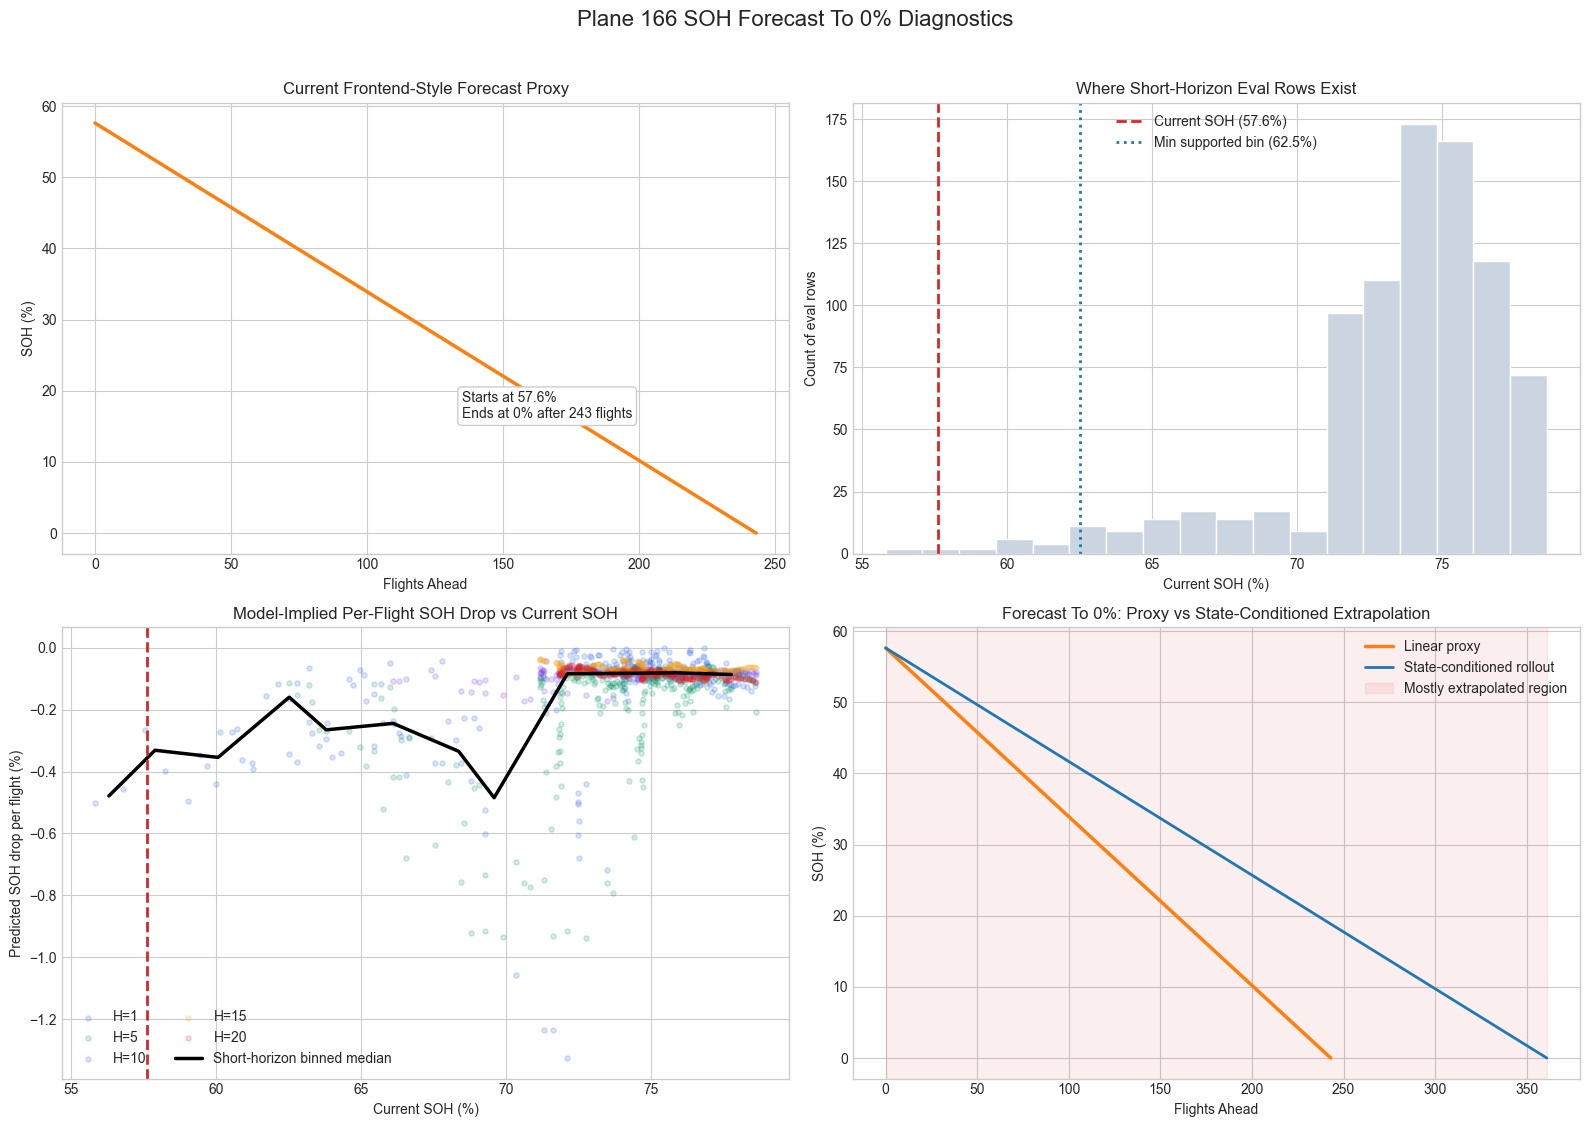

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1) Current frontend-style linear proxy
axes[0, 0].plot(linear_curve['flight_ahead'], linear_curve['soh'], color='tab:orange', linewidth=2.5)
axes[0, 0].set_title('Current Frontend-Style Forecast Proxy')
axes[0, 0].set_xlabel('Flights Ahead')
axes[0, 0].set_ylabel('SOH (%)')
axes[0, 0].annotate(
    f'Starts at {current_soh:.1f}%\nEnds at 0% after {rul_cycles} flights',
    xy=(linear_curve['flight_ahead'].iloc[-1], linear_curve['soh'].iloc[-1]),
    xytext=(0.55, 0.3),
    textcoords='axes fraction',
    bbox=dict(boxstyle='round', fc='white', ec='0.8'),
)

# 2) Model support across SOH state
axes[0, 1].hist(short_eval_df['current_soh'], bins=18, color='#cbd5e1', edgecolor='white')
axes[0, 1].axvline(current_soh, color='tab:red', linestyle='--', linewidth=2, label=f'Current SOH ({current_soh:.1f}%)')
if np.isfinite(min_supported_soh):
    axes[0, 1].axvline(min_supported_soh, color='tab:blue', linestyle=':', linewidth=2, label=f'Min supported bin ({min_supported_soh:.1f}%)')
axes[0, 1].set_title('Where Short-Horizon Eval Rows Exist')
axes[0, 1].set_xlabel('Current SOH (%)')
axes[0, 1].set_ylabel('Count of eval rows')
axes[0, 1].legend(loc='best')

# 3) Per-flight degradation implied by saved best models
horizon_colors = {1: '#2563eb', 5: '#059669', 10: '#7c3aed', 15: '#f59e0b', 20: '#dc2626'}
for horizon, frame in eval_df.groupby('horizon'):
    axes[1, 0].scatter(
        frame['current_soh'],
        frame['per_flight_drop'],
        s=14,
        alpha=0.18,
        color=horizon_colors.get(int(horizon), '#334155'),
        label=f'H={int(horizon)}',
    )
axes[1, 0].plot(bin_summary['current_mid'], bin_summary['per_flight_drop'], color='black', linewidth=2.5, label='Short-horizon binned median')
axes[1, 0].axvline(current_soh, color='tab:red', linestyle='--', linewidth=2)
axes[1, 0].set_title('Model-Implied Per-Flight SOH Drop vs Current SOH')
axes[1, 0].set_xlabel('Current SOH (%)')
axes[1, 0].set_ylabel('Predicted SOH drop per flight (%)')
axes[1, 0].legend(loc='best', ncol=2)

# 4) Linear proxy vs state-conditioned rollout
axes[1, 1].plot(linear_curve['flight_ahead'], linear_curve['soh'], color='tab:orange', linewidth=2.5, label='Linear proxy')
axes[1, 1].plot(state_curve['flight_ahead'], state_curve['soh'], color='tab:blue', linewidth=2.0, label='State-conditioned rollout')
if np.isfinite(min_supported_soh):
    unsupported_mask = state_curve['soh'] < min_supported_soh
    if unsupported_mask.any():
        first_unsupported = int(state_curve.loc[unsupported_mask, 'flight_ahead'].min())
        axes[1, 1].axvspan(first_unsupported, state_curve['flight_ahead'].max(), color='tab:red', alpha=0.08, label='Mostly extrapolated region')
axes[1, 1].set_title('Forecast To 0%: Proxy vs State-Conditioned Extrapolation')
axes[1, 1].set_xlabel('Flights Ahead')
axes[1, 1].set_ylabel('SOH (%)')
axes[1, 1].legend(loc='best')

fig.suptitle(f'Plane {plane_id} SOH Forecast To 0% Diagnostics', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Interpretation

Use this notebook to answer three separate questions:

1. **Why does the frontend line look linear?**
   Because the current frontend overlay is a linear proxy from latest SOH to `replacementDatePred`. It is not a recursive model rollout.

2. **Do the saved multihorizon models imply nonlinear degradation?**
   Sometimes yes, but only weakly and inconsistently. The scatter / binned-median plot shows whether predicted per-flight degradation changes with state.

3. **Is a forecast all the way to 0% supported by the data?**
   For plane 166, usually no. If current SOH is already below the lowest well-supported SOH band in the short-horizon eval rows, then nearly the whole rollout to 0% is extrapolation.

Practical implication:
- A trustworthy long-range SOH trajectory should come from a dedicated recursive forecast engine, not from a straight-line interpolation and not from naively extending fixed-horizon point predictions.
- If we want a realistic non-linear curve, we need either:
  - more low-SOH data, or
  - an explicit degradation model with state evolution rules that can be rolled forward flight by flight.